EKSPORACYJNA ANALIZA DANYCH spectrogram_stats

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import math
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

In [4]:
df0 = pd.read_csv("https://raw.githubusercontent.com/PawelMozaryn/CNNs-librosa/refs/heads/final_files/extracted.csv")
gl = pd.read_csv("https://raw.githubusercontent.com/PawelMozaryn/CNNs-librosa/refs/heads/final_files/good_labels.csv")

In [5]:
df = pd.merge(df0, gl, on='track_id', how='inner')
df.rename(columns={'track_genre': 'genre'}, inplace=True)

In [ ]:
df.info()
#sprawdzamy na wszelki wypadek czy napewno nie ma braków danych - jest ok, dane są poprawne

#class imbalance zostało już wcześniej naprawione w pliku 'eda'

#Zawiera 7991 rekordów i 64 kolumny.

#Dane są kompletne (brak wartości NaN w żadnej kolumnie)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 65 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   track_id        7991 non-null   int64  
 1   duration_s      7991 non-null   float64
 2   rms_mean        7991 non-null   float64
 3   rms_std         7991 non-null   float64
 4   zcr_mean        7991 non-null   float64
 5   zcr_std         7991 non-null   float64
 6   centroid_mean   7991 non-null   float64
 7   centroid_std    7991 non-null   float64
 8   bandwidth_mean  7991 non-null   float64
 9   bandwidth_std   7991 non-null   float64
 10  rolloff_mean    7991 non-null   float64
 11  rolloff_std     7991 non-null   float64
 12  flatness_mean   7991 non-null   float64
 13  flatness_std    7991 non-null   float64
 14  mfcc1_mean      7991 non-null   float64
 15  mfcc1_std       7991 non-null   float64
 16  mfcc2_mean      7991 non-null   float64
 17  mfcc2_std       7991 non-null   f

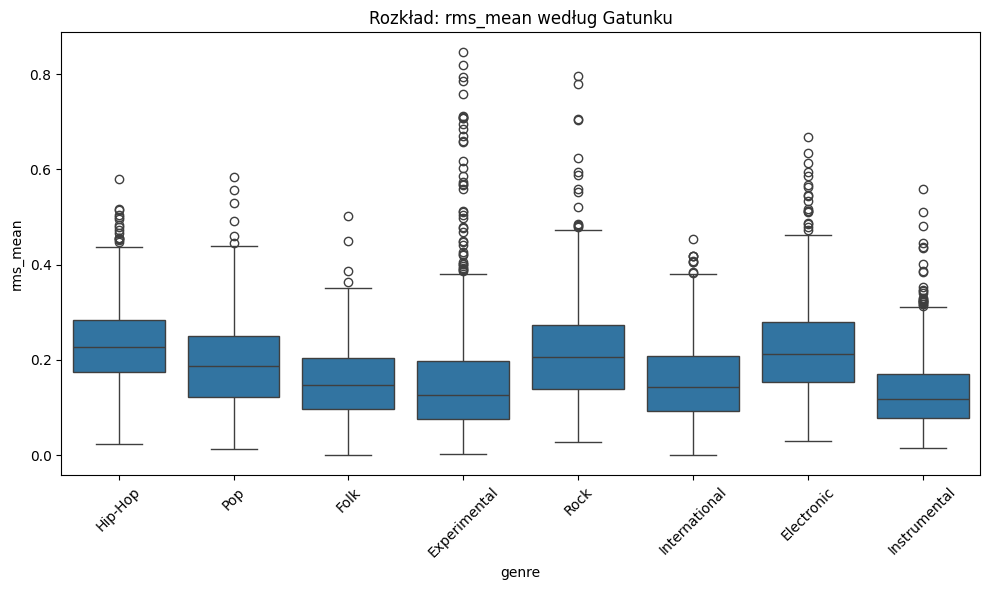

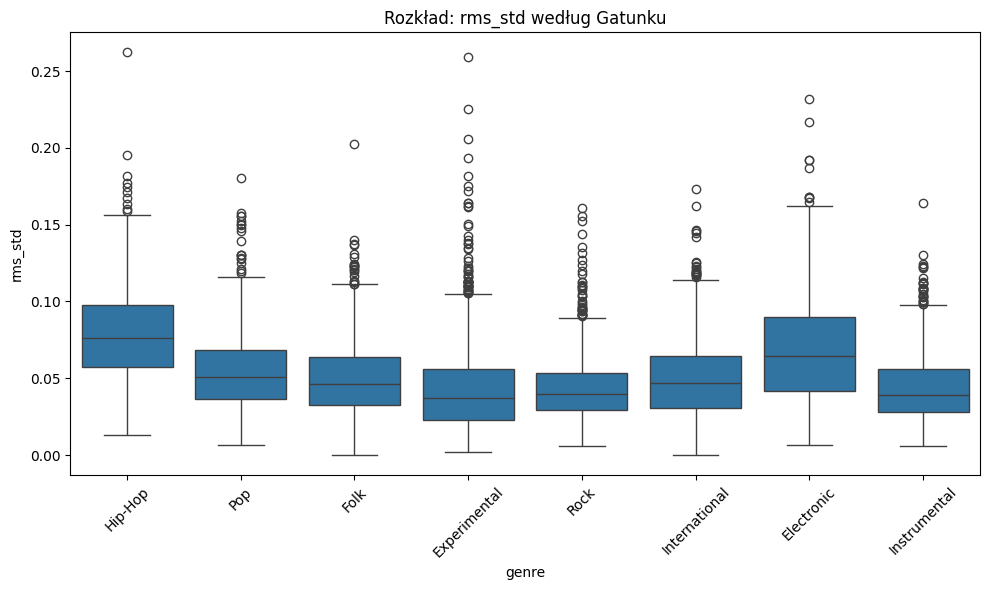

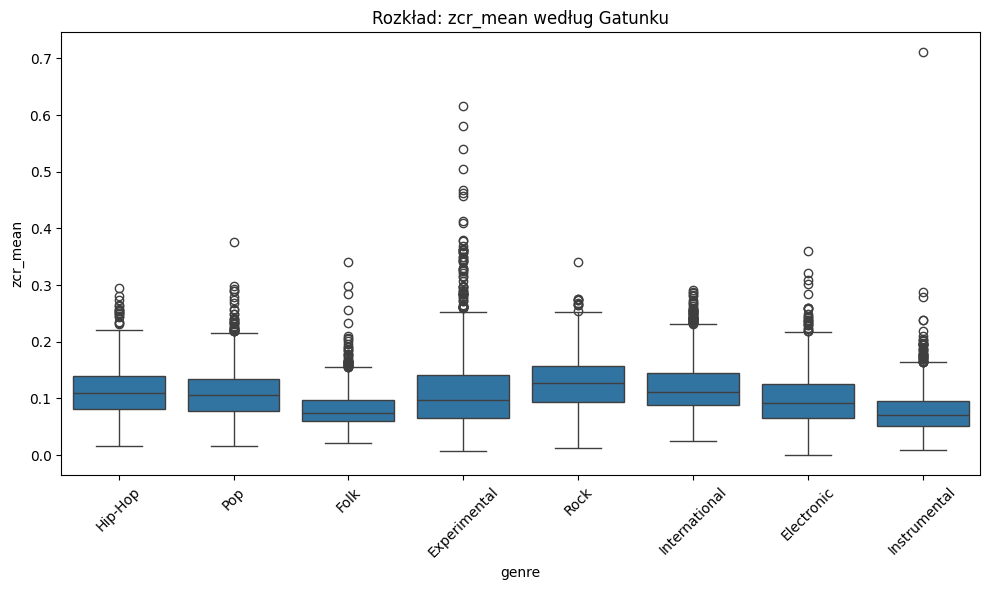

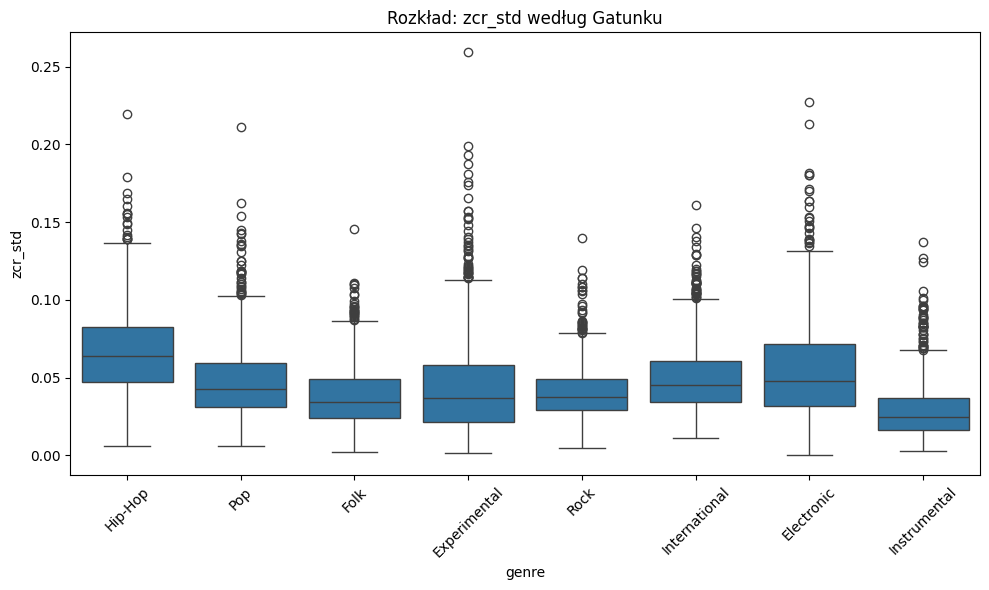

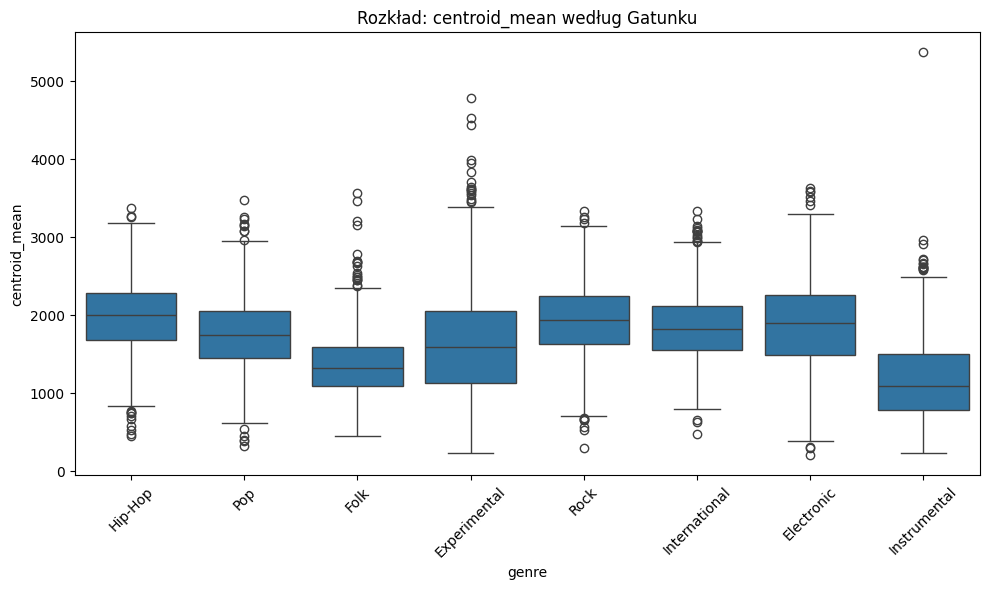

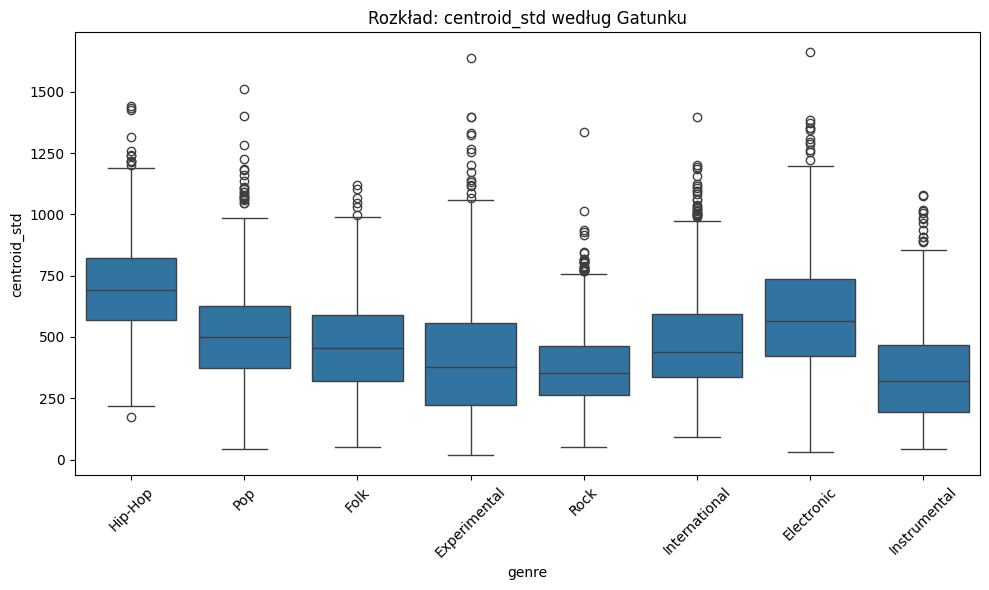

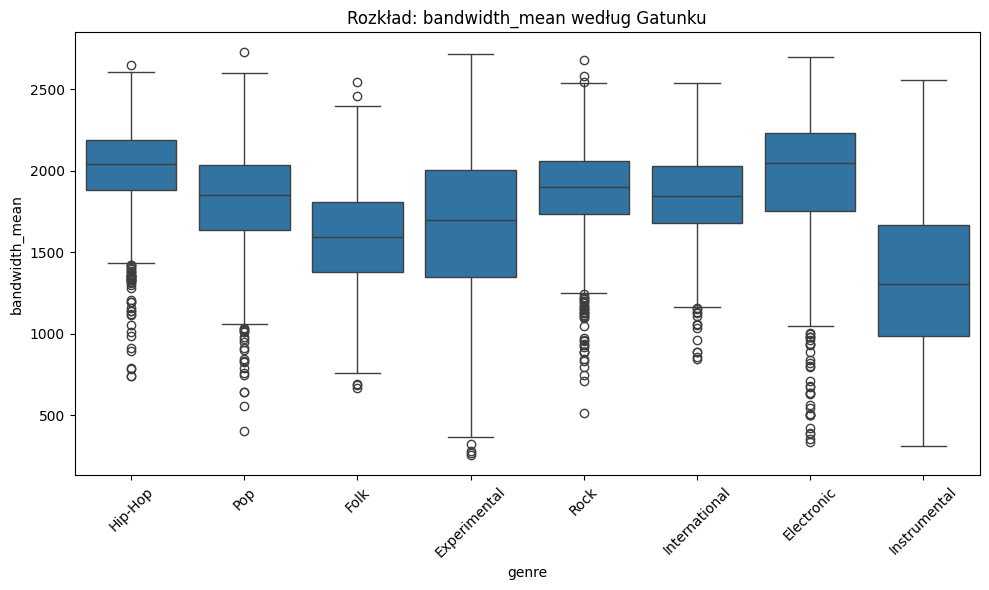

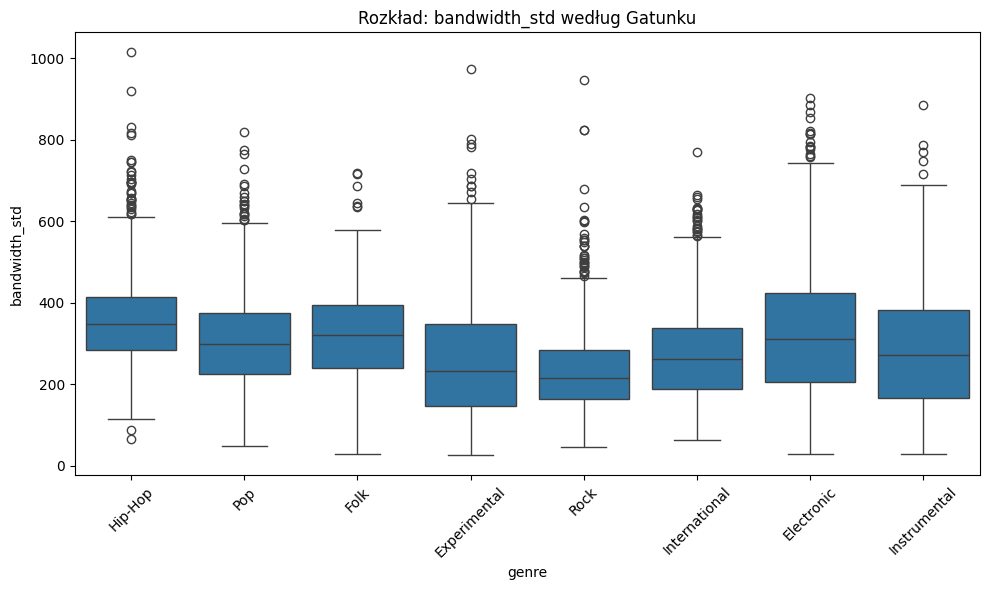

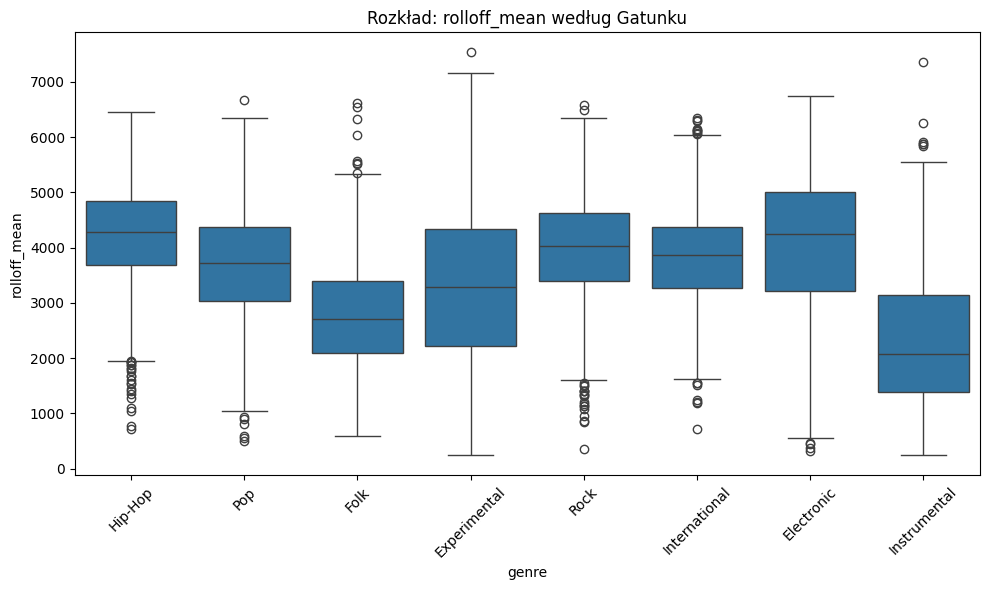

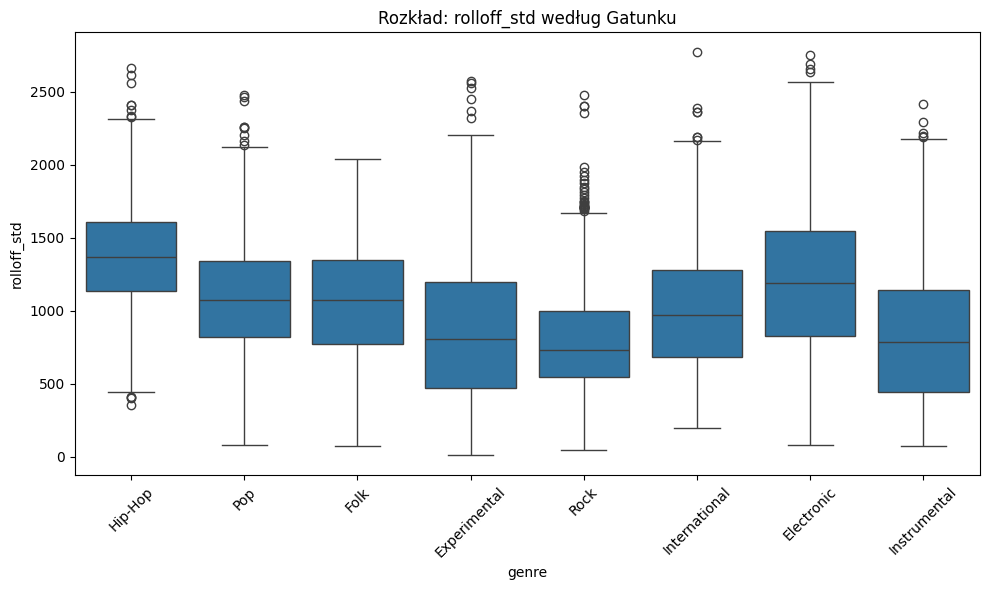

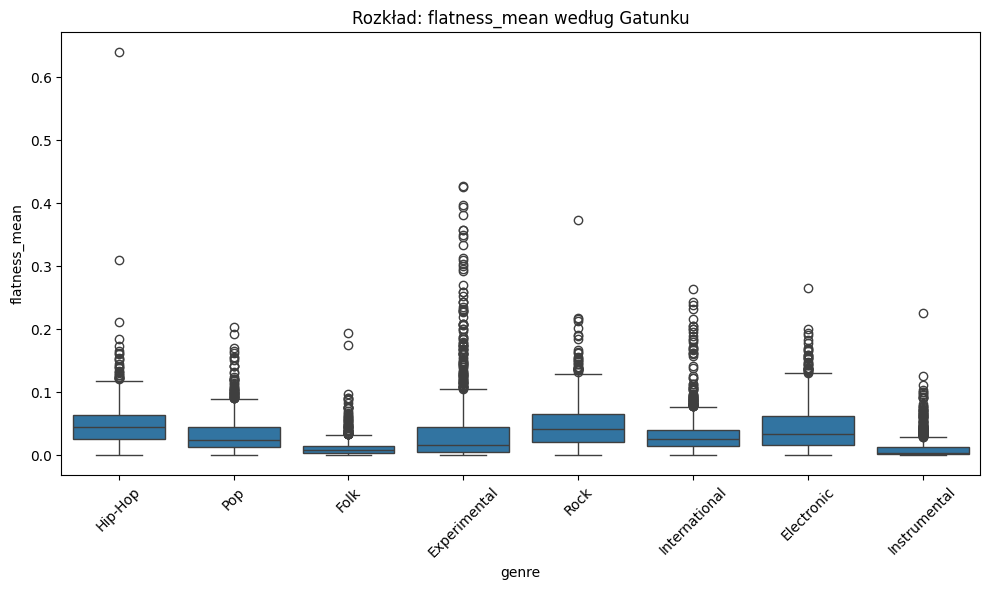

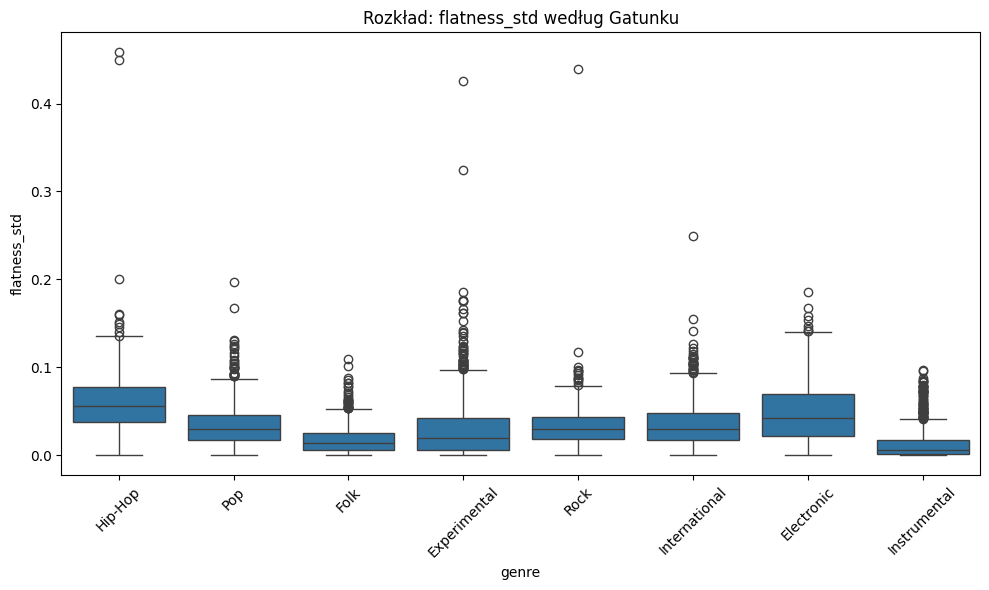

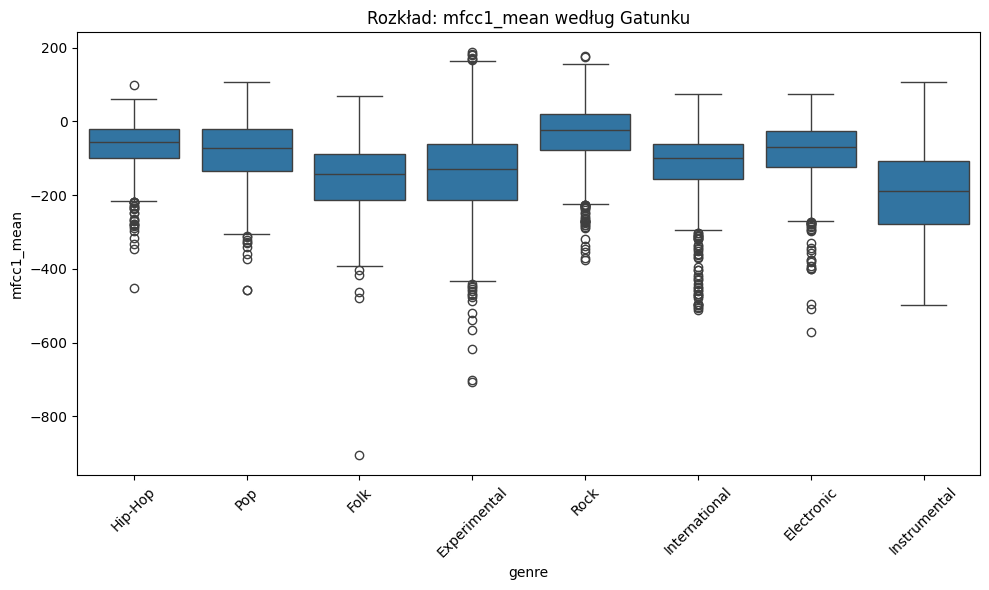

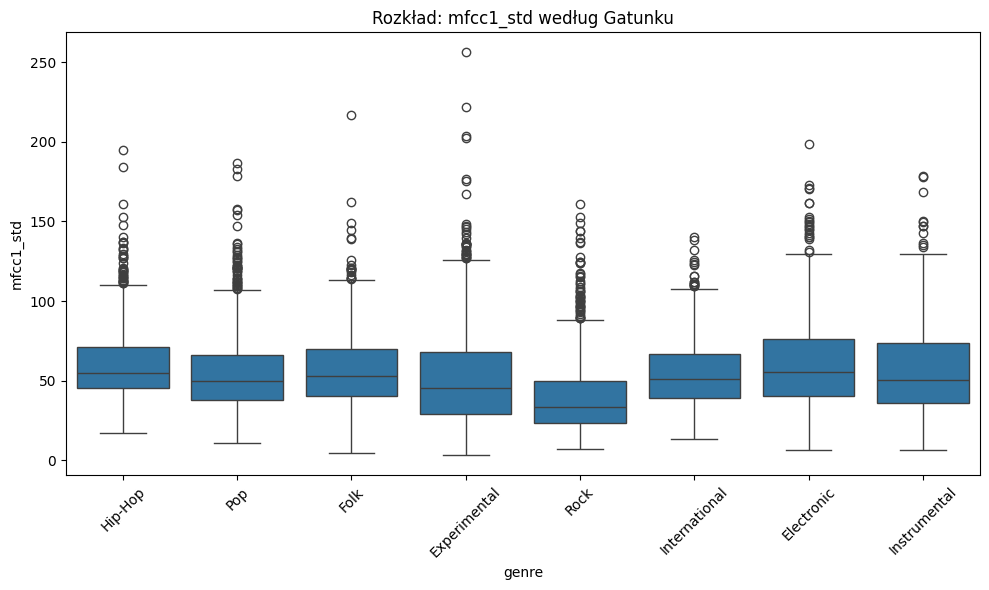

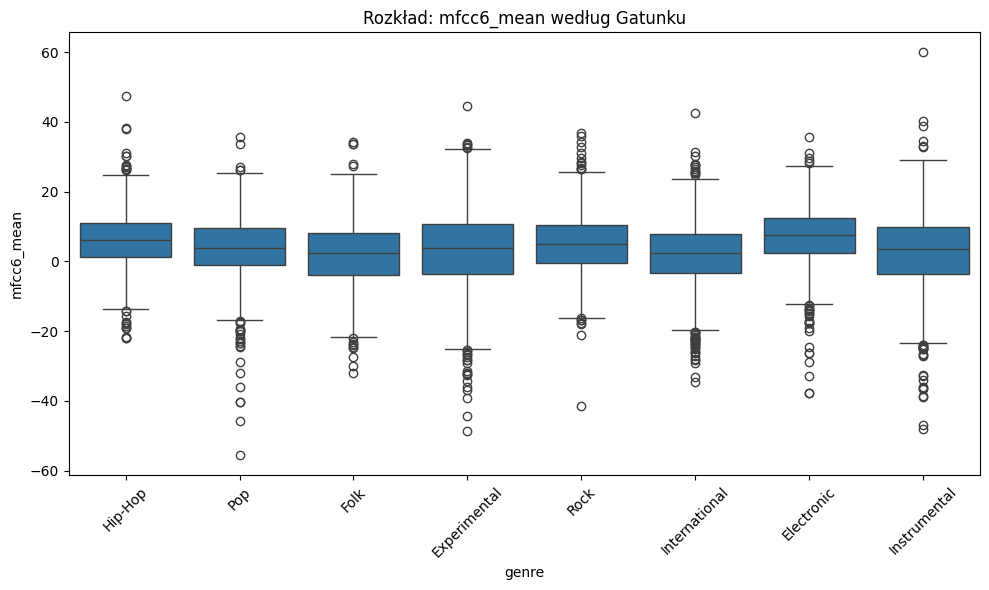

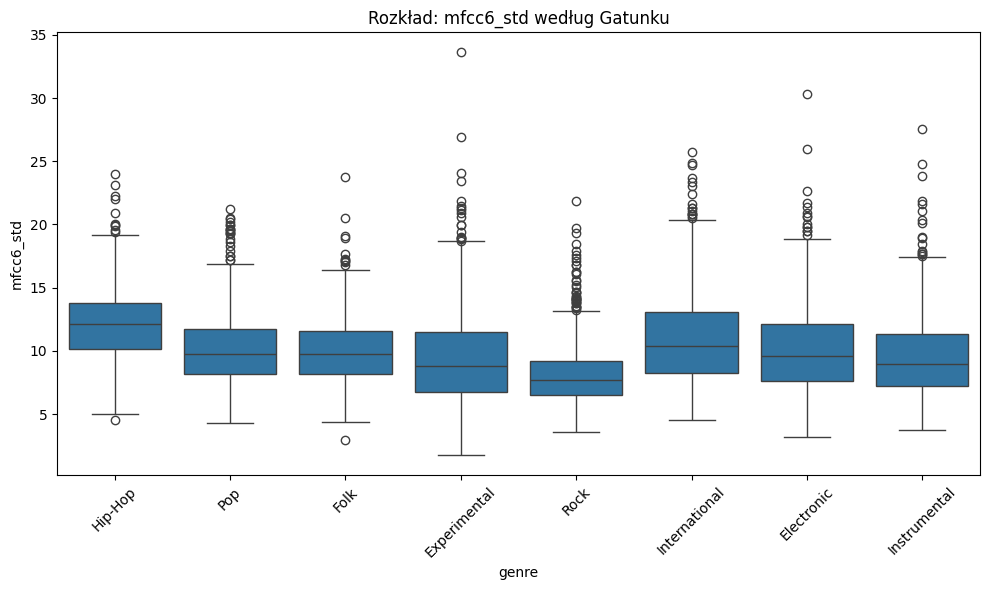

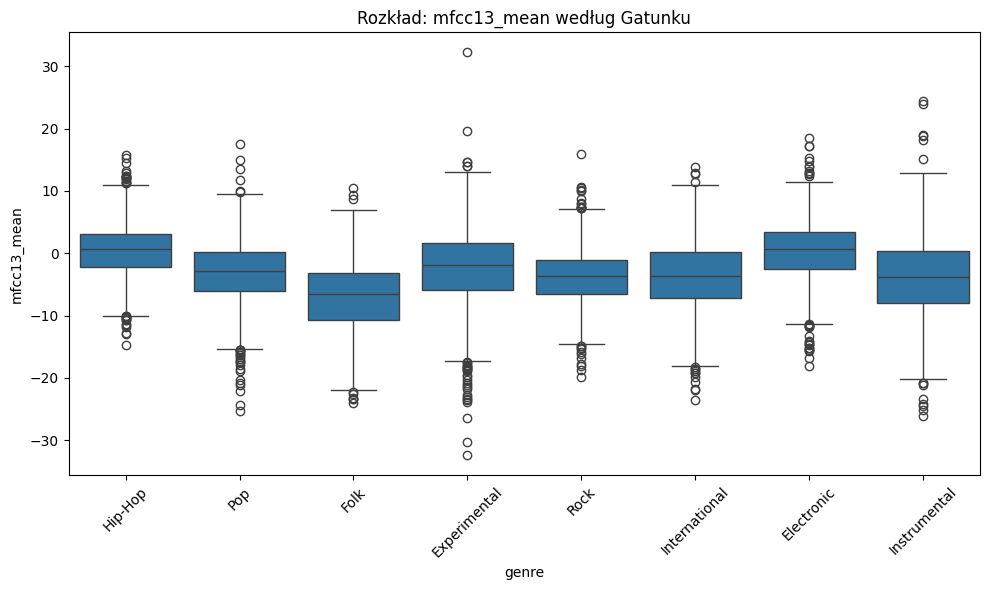

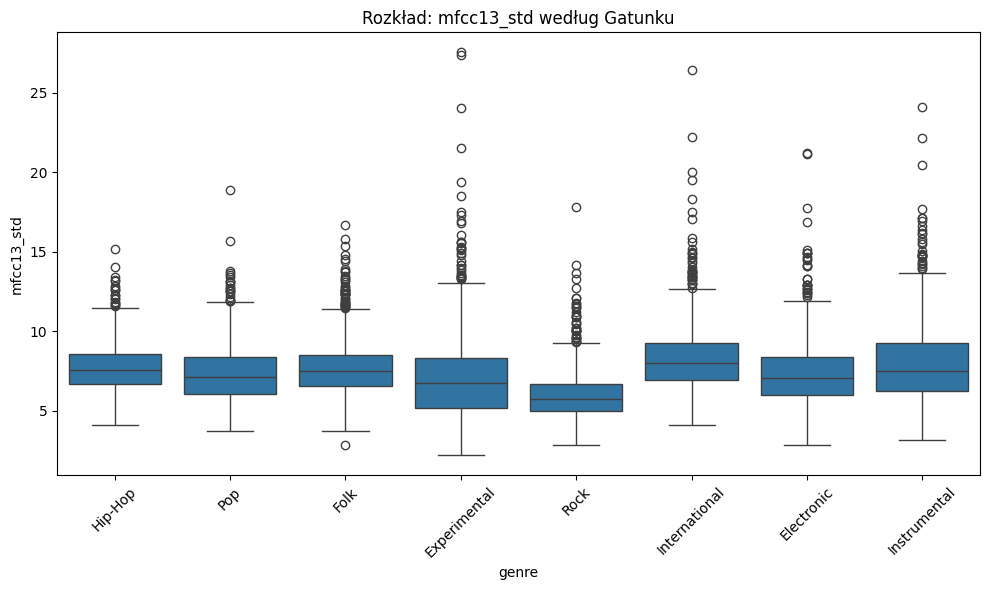

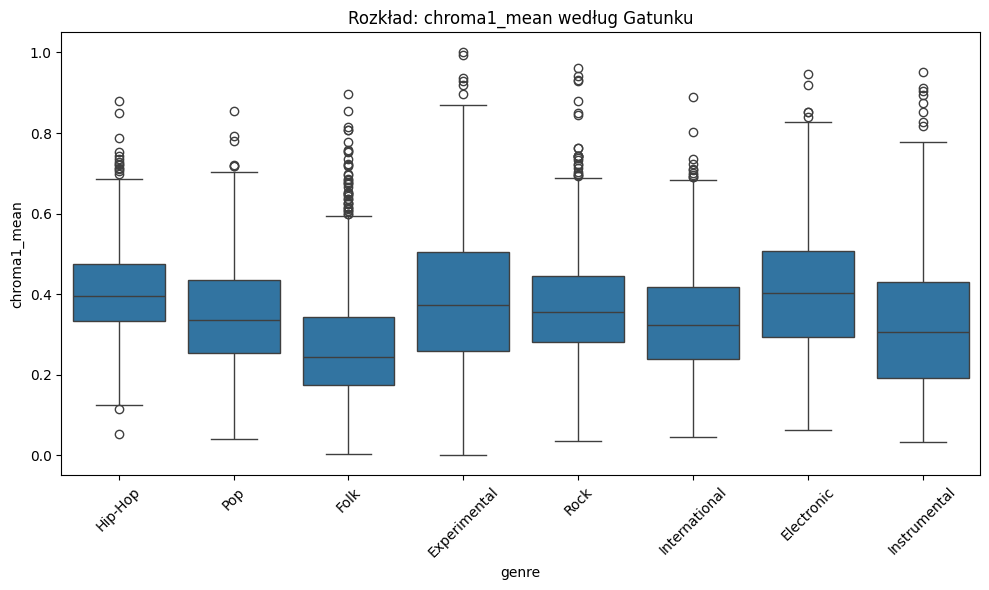

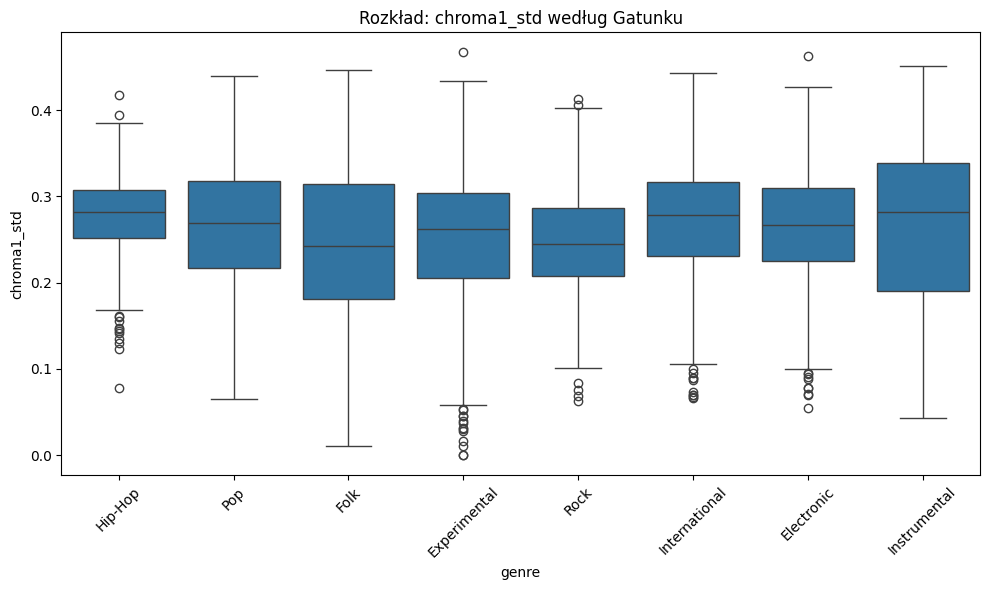

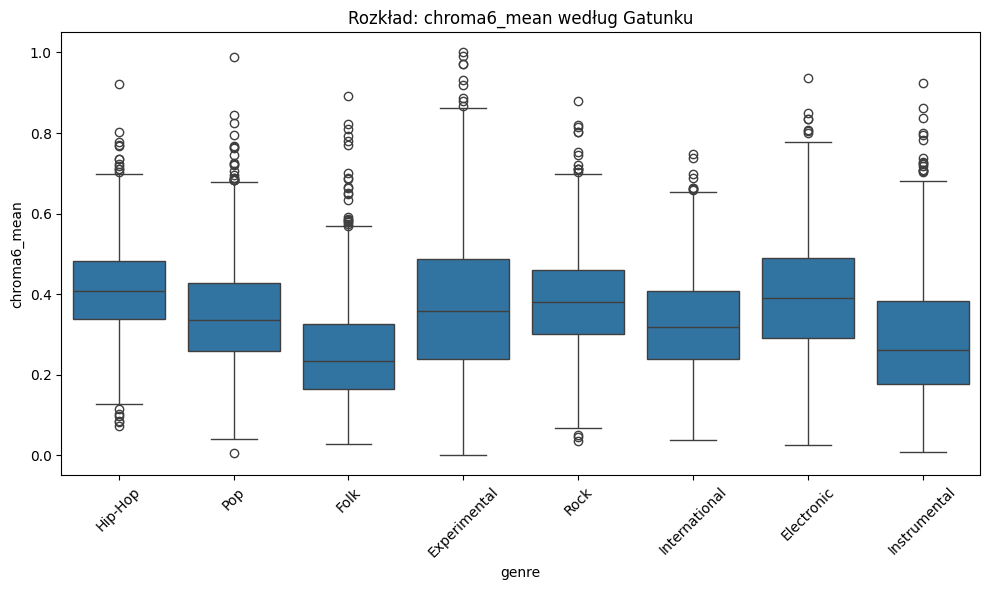

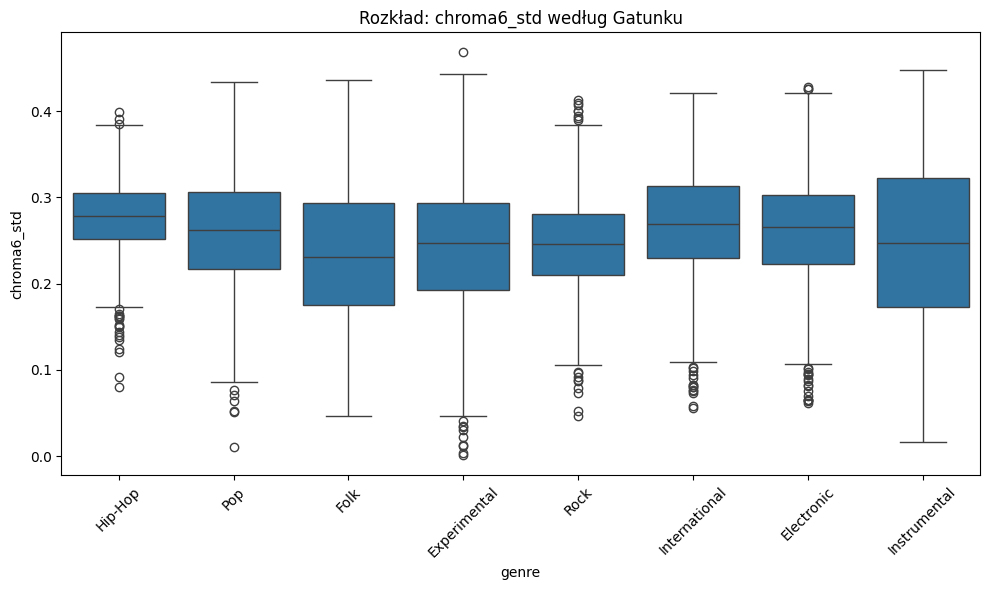

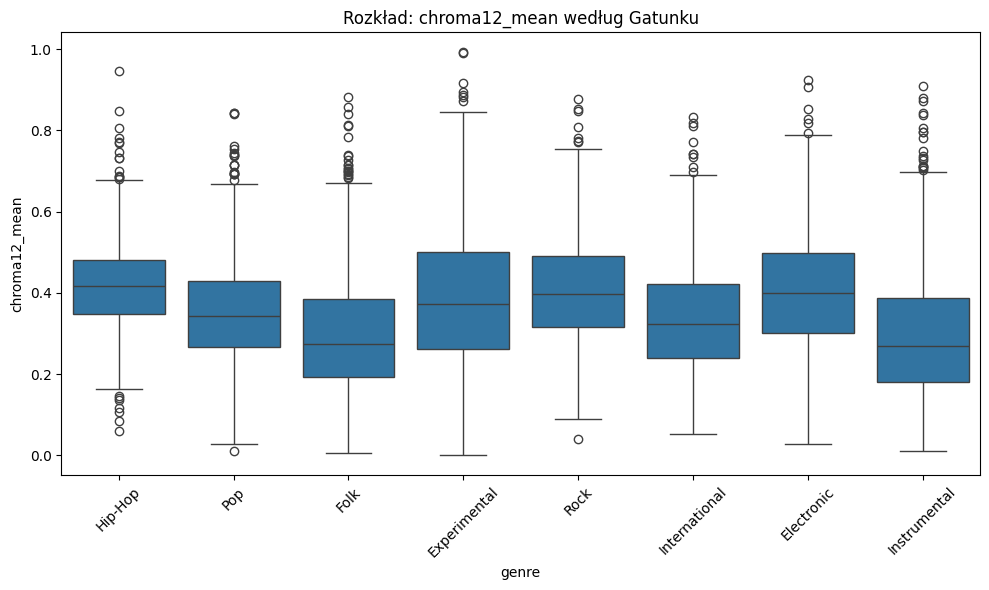

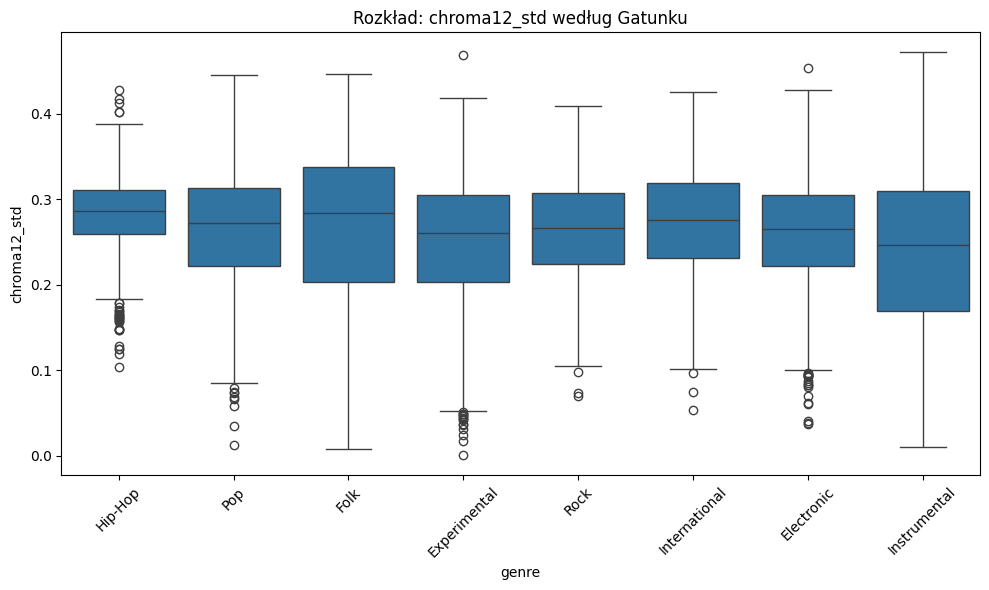

In [10]:

# 3. Poprawnośćdanych i outliers
# wybieramy kolumny numeryczne
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'track_id' in num_cols:
    num_cols.remove('track_id')

key_features = [
    #'track_id', #'duration_s' bez różnicy,
    'rms_mean', 'rms_std',
    'zcr_mean', 'zcr_std', 
    'centroid_mean', 'centroid_std',
    'bandwidth_mean', 'bandwidth_std',
    'rolloff_mean', 'rolloff_std',
    'flatness_mean', 'flatness_std',
    'mfcc1_mean', 'mfcc1_std',
    'mfcc6_mean', 'mfcc6_std',
    'mfcc13_mean', 'mfcc13_std',
    'chroma1_mean', 'chroma1_std',
    'chroma6_mean', 'chroma6_std',
    'chroma12_mean', 'chroma12_std']
plot_features = [f for f in key_features if f in df.columns]


# Pętla generująca wykresy
for col in plot_features:
    # Tworzymy nową figurę dla każdego wykresu osobno
    plt.figure(figsize=(10, 6)) 
    
    # Rysujemy wykres
    sns.boxplot(x='genre', y=col, data=df)
    
    # Kosmetyka
    plt.title(f'Rozkład: {col} według Gatunku')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Wyświetlenie wykresu
    plt.show()
    


  

In [ ]:
#WNIOSKI:

#Wykresy pudełkowe pokazują, że wiele cech nieźle różnicuje gatunki

#Obserwacje odstające: Widoczne są liczne outliery,
#szczególnie w rms_mean

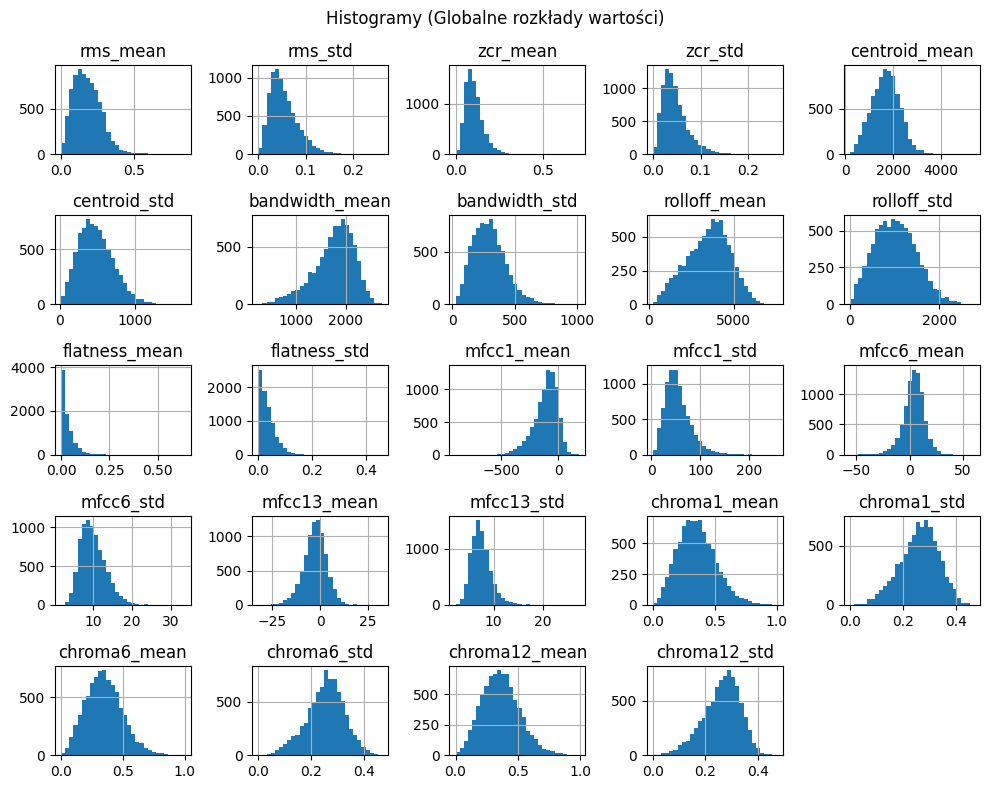

In [11]:
# 4. histogramy wartości dla globalnych
df[plot_features].hist(bins=30, figsize=(10, 8))
plt.suptitle('Histogramy (Globalne rozkłady wartości)')
plt.tight_layout()


In [12]:
#Histogramy: Globalne rozkłady cech są często niesymetryczne (skośne),
#  co sugeruje, że w docelowym modelu warto zastosować będzie normalizację (np. StandardScaler),
# co uwzględnimy w takim razie w teście dla kNNa tak samo jak w pierwszej EDA

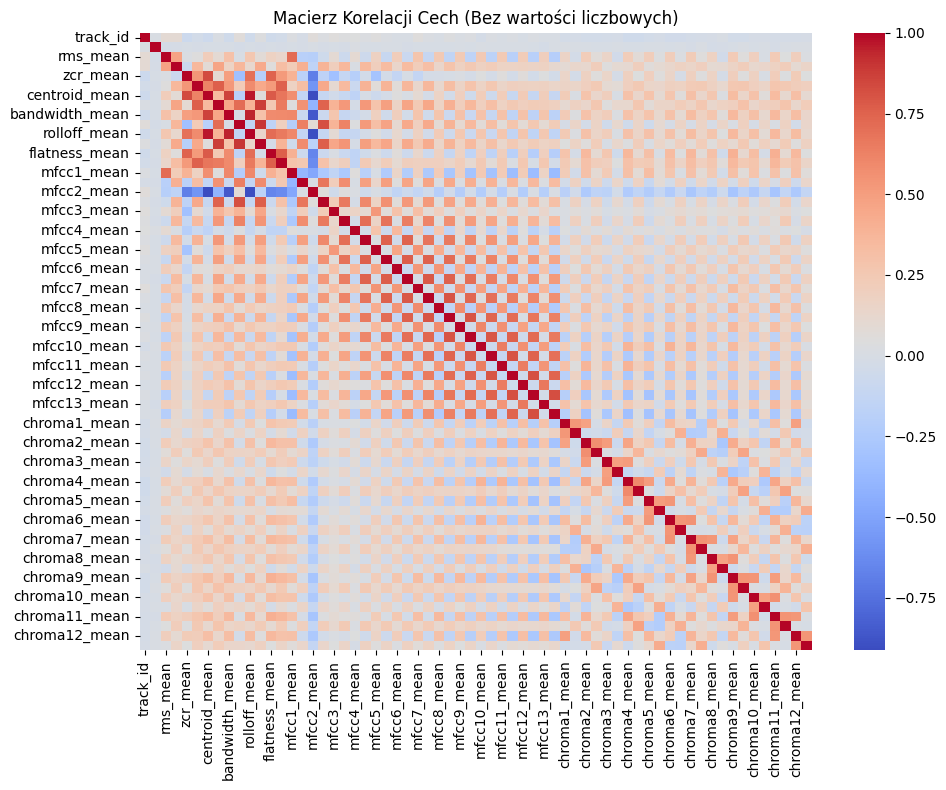

In [15]:
# 5. Correlation Matrix

# Usuwamy 'min' (bo jest stała) oraz 'track_id'
#cols_to_drop = ['min']
# Sprawdzamy, czy kolumny istnieją przed usunięciem
#existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]

# Wybieramy tylko numeryczne kolumny i usuwamy te niechciane
numeric_df = df.select_dtypes(include=[np.number])

# Generowanie macierzy korelacji
plt.figure(figsize=(10, 8))
corr = numeric_df.corr()

# Rysowanie mapy ciepła
sns.heatmap(corr, annot=False, cmap='coolwarm')

plt.title('Macierz Korelacji Cech (Bez wartości liczbowych)')
plt.tight_layout()
plt.show()

In [ ]:
#występuje małą korelacja cech!

Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- NAJLEPSZE PARAMETRY ---
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 10, 'knn__weights': 'distance'}
Best CV score (średnia z walidacji): 0.4616

--- FINAL REPORT (Zbiór testowy) ---
Test Accuracy: 0.4737
               precision    recall  f1-score   support

   Electronic       0.54      0.30      0.39       300
 Experimental       0.58      0.21      0.31       299
         Folk       0.47      0.62      0.53       300
      Hip-Hop       0.47      0.74      0.57       299
 Instrumental       0.56      0.48      0.52       300
International       0.46      0.56      0.50       300
          Pop       0.29      0.25      0.27       300
         Rock       0.52      0.63      0.57       300

     accuracy                           0.47      2398
    macro avg       0.48      0.47      0.46      2398
 weighted avg       0.48      0.47      0.46      2398



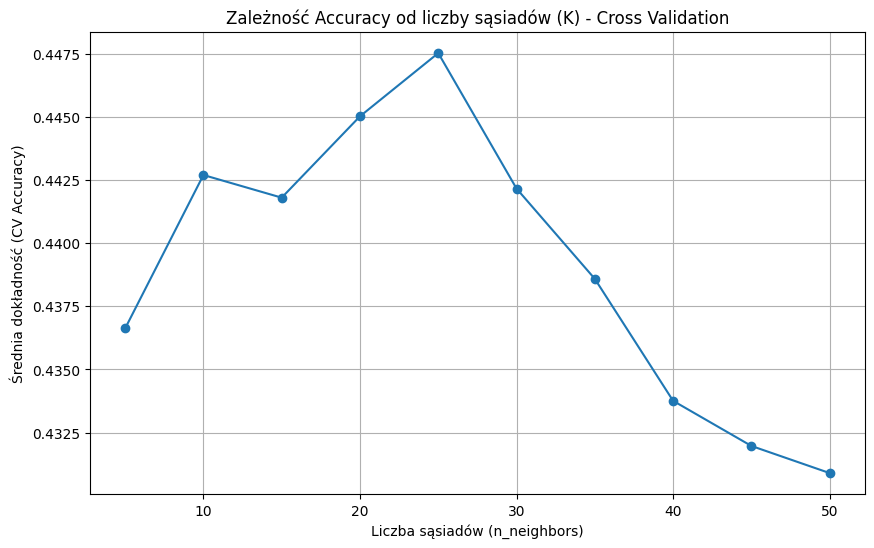

In [16]:
###znajdźmy wstępnie 'sensownego' kNNa i sprawdźmy jak sobie radzi

cols_to_drop = ['track_id'] 
# Upewniamy się, że usuwamy tylko te, które istnieją
existing_drop = [c for c in cols_to_drop if c in df.columns]
X = df.drop(columns=['genre'] + existing_drop)
y = df['genre']
# Encoding etykiet
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Podział na zbiór treningowy i ostateczny testowy
# Walidację krzyżową będziemy robić na X_train_val
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=123, stratify=y_encoded)

#Budowa Pipeline'u
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

#Definicja siatki parametrów
param_grid = {
    'knn__n_neighbors': list(range(5, 55, 5)),
    'knn__weights': ['uniform', 'distance'], 
    'knn__metric': ['euclidean', 'manhattan']
}

#Uruchomienie GridSearchCV z Walidacją Krzyżową
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_val, y_train_val)

#wyniki
print("\n--- NAJLEPSZE PARAMETRY ---")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score (średnia z walidacji): {grid_search.best_score_:.4f}")

#miara na testowym
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- FINAL REPORT (Zbiór testowy) ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# (Opcjonalnie) Wizualizacja wyników dla n_neighbors (dla domyślnych wag i metryki)
results = pd.DataFrame(grid_search.cv_results_)
# Filtrujemy tylko dla wariantu uniform/euclidean żeby wykres był czytelny
subset = results[
    (results['param_knn__weights'] == 'uniform') & 
    (results['param_knn__metric'] == 'euclidean')
]

plt.figure(figsize=(10, 6))
plt.plot(subset['param_knn__n_neighbors'], subset['mean_test_score'], marker='o')
plt.title('Zależność Accuracy od liczby sąsiadów (K) - Cross Validation')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Średnia dokładność (CV Accuracy)')
plt.grid(True)
plt.show()

In [17]:
#Dokładność (Accuracy): dla najlepszego k mamy aż 44%
#Punkt odniesienia (losowy): Przy 8 klasach losowe zgadywanie dałoby wynik ok. 12.5%.

#Wniosek: Cechy dźwiękowe dają całkiem niezły wynik